Libraries Loaded

Dataset Loaded


Access is denied.


,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149



Dataset Shape: (81, 5)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HP      81 non-null     int64  
 1   MPG     81 non-null     float64
 2   VOL     81 non-null     int64  
 3   SP      81 non-null     float64
 4   WT      81 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.3 KB
None

Missing Values
HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

Duplicate Rows: 0

Data Cleaning Completed

Summary Statistics


,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


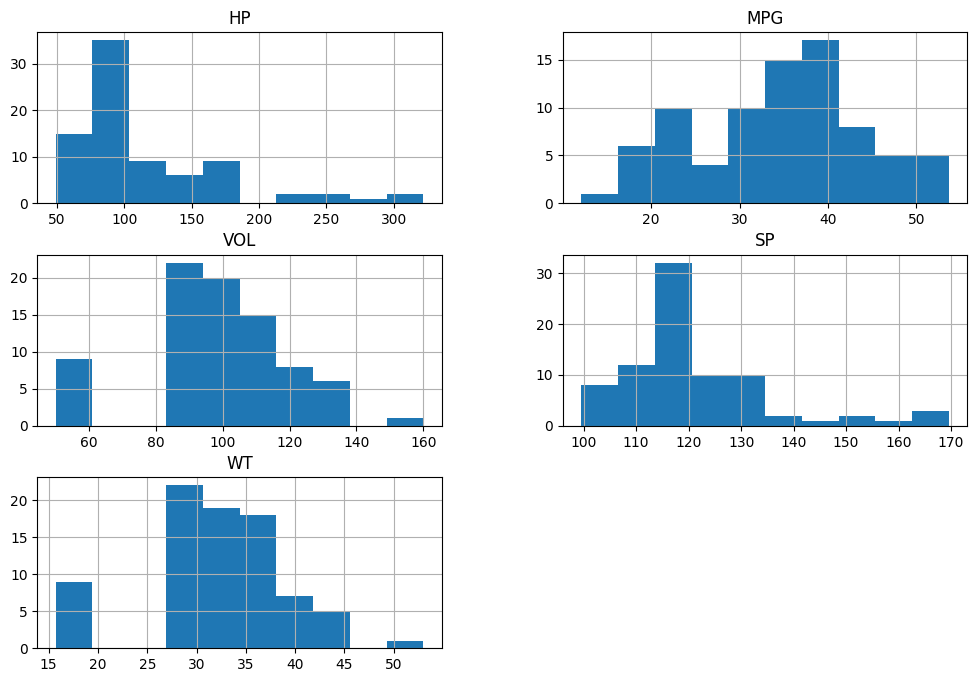

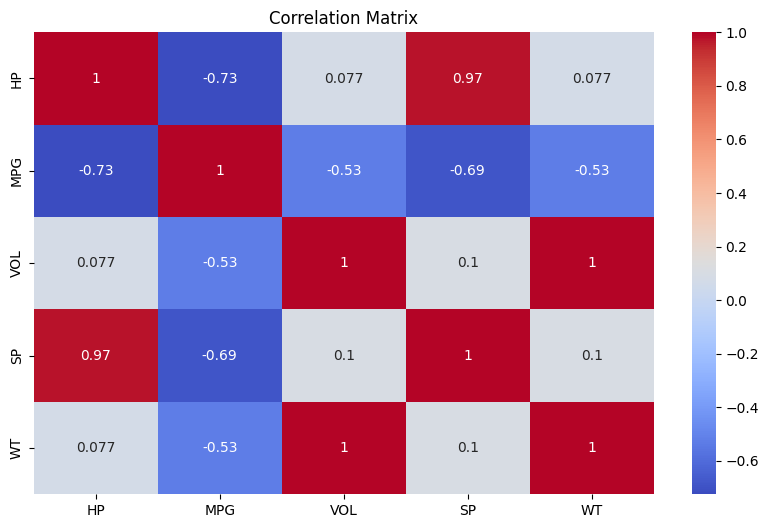


Auto Insights
Rows: 81
Columns: 5
Missing Values: 0
Highest Average Column: SP

Target Column: WT

Feature Engineering Completed

Data Split Completed

Regression Problem Detected
R2 Score: 0.8844173529945084

Sample Prediction: [37.49506845]

Model Saved as ai_model.pkl

Report Generated


,rows,columns,missing_values,model_score
0,81,5,0,0.884417



AI DATA ANALYSIS PIPELINE COMPLETED


In [28]:
# ================================
# AI DATA ANALYZER - FULL PIPELINE
# ================================

# Install libraries (run once)
!pip install pandas numpy matplotlib seaborn scikit-learn joblib --quiet

# ================================
# 1 IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score

import joblib
import warnings
warnings.filterwarnings("ignore")

print("Libraries Loaded")

# ================================
# 2 LOAD DATASET
# ================================

file_path = "Cars.csv"  # replace with your dataset path

df = pd.read_csv(file_path)

print("\nDataset Loaded")

display(df.head())

# ================================
# 3 DATA VALIDATION
# ================================

print("\nDataset Shape:", df.shape)

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# ================================
# 4 DATA CLEANING
# ================================

df = df.drop_duplicates()

df = df.fillna(method="ffill")

print("\nData Cleaning Completed")

# ================================
# 5 AUTOMATED EDA
# ================================

print("\nSummary Statistics")
display(df.describe())

# Distribution plots
df.hist(figsize=(12,8))
plt.show()

# Correlation heatmap
numeric = df.select_dtypes(include=["int64","float64"])

if not numeric.empty:

    plt.figure(figsize=(10,6))

    sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")

    plt.title("Correlation Matrix")

    plt.show()

# ================================
# 6 INSIGHT GENERATION
# ================================

print("\nAuto Insights")

rows, cols = df.shape

print("Rows:", rows)
print("Columns:", cols)

missing = df.isnull().sum().sum()

print("Missing Values:", missing)

numeric_cols = df.select_dtypes(include="number")

if not numeric_cols.empty:

    highest = numeric_cols.mean().idxmax()

    print("Highest Average Column:", highest)

# ================================
# 7 TARGET SELECTION
# ================================

target = df.columns[-1]   # last column as target

print("\nTarget Column:", target)

X = df.drop(columns=[target])

y = df[target]

# ================================
# 8 FEATURE ENGINEERING
# ================================

X = pd.get_dummies(X)

if y.dtype == "object":

    le = LabelEncoder()

    y = le.fit_transform(y)

print("\nFeature Engineering Completed")

# ================================
# 9 TRAIN TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

print("\nData Split Completed")

# ================================
# 10 AUTOMATIC MODEL SELECTION
# ================================

if len(np.unique(y)) <= 20:

    print("\nClassification Problem Detected")

    model = RandomForestClassifier()

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    score = accuracy_score(y_test,pred)

    print("Accuracy:",score)

else:

    print("\nRegression Problem Detected")

    model = RandomForestRegressor()

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    score = r2_score(y_test,pred)

    print("R2 Score:",score)

# ================================
# 11 PREDICTION TEST
# ================================

sample = X_test.iloc[0:1]

prediction = model.predict(sample)

print("\nSample Prediction:", prediction)

# ================================
# 12 SAVE MODEL
# ================================

joblib.dump(model,"ai_model.pkl")

print("\nModel Saved as ai_model.pkl")

# ================================
# 13 GENERATE REPORT
# ================================

report = {
    "rows": rows,
    "columns": cols,
    "missing_values": missing,
    "model_score": score
}

report_df = pd.DataFrame([report])

report_df.to_csv("analysis_report.csv",index=False)

print("\nReport Generated")

display(report_df)

print("\nAI DATA ANALYSIS PIPELINE COMPLETED")